## Modeling Example Notebook for DTSC 4302

This notebook serves as a reference for how to use the personally defined APIs in order to run and interpret Mixed Effects Models in this project.

In [1]:
# non built-in libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# built-in libraries
import os
import json
from pathlib import Path
import sys
import datetime
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# personally-defined modules
sys.path.append(os.path.join(str(Path.cwd()), "../"))  
from scripts.data_download import download_files_from_fld
from scripts.modeling.mixed_model_wrapper import fit_mixed_model, plot_diagnostics, anova_mixed_models

# install reqd. datasets from Google Drive
folder_id = "1P2FRAkPrqL2nn2MNMyd4ilWbXNS_kkKD" 
data_path = os.path.join(str(Path.cwd()), "../data")
download_files_from_fld(folder_id, data_path)

# constants
START_DATE = datetime.datetime(2013, 10, 1)  # init start date of analysis to first day of FY 2014
END_DATE = datetime.datetime(2024, 9, 30)  # init end date of analysis to last day of FY 2024

# reading in data
sent_df = pd.read_csv(os.path.join(data_path, "sentencing_data_cleaned.csv"), low_memory=False)
districts_gdf = gpd.read_file(os.path.join(data_path, "us_district_cts_bounds.geojson"))
districts_gdf = districts_gdf.rename(columns={c: c.upper() for c in districts_gdf.columns})
districts_gdf = districts_gdf[["NAME", "DISTRICT_N", "GEOMETRY"]]

Retrieving folder contents


Processing file 1JATvvOEw2llpX52TuAeza9C76YnBPiIj county_to_jud_district_xref.csv
Processing file 1r9L2VUSg_j9t2CsSYOnyi3HzYXyyd64U election_results_2000-2024_MIT.csv
Processing file 1oGg1ge9gVHoMdTDmYh6kVvcqZoG8ojXi judges.csv
Processing file 1MDpg6-mgFGDUhPUV3v2DfP3sEQZ4sXjf JUSTFAIR_clean.csv
Processing file 1J-CyKS2pQ9U27yKvbgBk2dWgy_JooAor opafy14_24_combined_filtered.csv
Processing file 1csaA1FQPNk_8PVJlrhoAnD0-27IwP0jz sentencing_data_cleaned.csv
Processing file 1l7nAYrXHOMcLnyAf5FpcfmKL1A-9f1_U us_district_cts_bounds.geojson


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1JATvvOEw2llpX52TuAeza9C76YnBPiIj
To: c:\Users\ajhay\USSC-Fairness-Analysis-DTSC-430X-Capstone-\data\county_to_jud_district_xref.csv
100%|██████████| 320k/320k [00:00<00:00, 9.28MB/s]
Downloading...
From: https://drive.google.com/uc?id=1r9L2VUSg_j9t2CsSYOnyi3HzYXyyd64U
To: c:\Users\ajhay\USSC-Fairness-Analysis-DTSC-430X-Capstone-\data\election_results_2000-2024_MIT.csv
100%|██████████| 10.2M/10.2M [00:00<00:00, 50.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1oGg1ge9gVHoMdTDmYh6kVvcqZoG8ojXi
To: c:\Users\ajhay\USSC-Fairness-Analysis-DTSC-430X-Capstone-\data\judges.csv
100%|██████████| 5.42M/5.42M [00:00<00:00, 30.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MDpg6-mgFGDUhPUV3v2DfP3sEQZ4sXjf
To: c:\Users\ajhay\USSC-Fairness-Analysis-DTSC-430X-Capstone-\data\JUSTFAIR_clean.csv
100%|██████████| 25.6M/25.6M 

## Example Model Run # 1

This is an example showing a simple model fit on the sentencing data with random intercepts for each district and a global intercept. This example also shows how to interpret the results of the model.

In [ ]:
# filter to only include people who received atleast one month of prison
expmnt_df = sent_df[sent_df["MNTHS_PRSN_NO_ALT"] > 1].copy()

# scale MNTHS_PRSN_NO_ALT to reduce runtime of mixed model fitting and help convergence
expmnt_df["MNTHS_PRSN_NO_ALT"] = expmnt_df["MNTHS_PRSN_NO_ALT"] / 12  

expmnt_df["MNTHS_PRSN_NO_ALT"] = np.log(expmnt_df["MNTHS_PRSN_NO_ALT"])  # log transform to reduce skew

result = fit_mixed_model(
    expmnt_df[["MNTHS_PRSN_NO_ALT", "DIST_CRT"]],   # only inlcude columns used in formula to save time
    formula="MNTHS_PRSN_NO_ALT ~ (1 | DIST_CRT)",  # use "||" instead of "|" to enforce diagonal covariance structure
    family="gaussian",  # binomial if outcome is binary
    link=None,  # must be None for family="gaussian", see docstring for more details
    categorical_cols=["DIST_CRT"],  # all columns that you want to be treated as categorical
    reference_levels = None,
    return_confint=False,  # return confidence intervals for fixed effects
    return_random_effects_variance=True,
    return_random_effects_covariance=True,  # return covariance matrices for random effects.
    return_fitted=True,  # return fitted values (reqd for calling plot_diagnostics function). Set to False if you want to save time and dont care about diagnostics
    return_residuals=True,  # return pearson studentized residuals (reqd for calling plot_diagnostics function). Set to False if you want to save time and dont care about diagnostics
    optimizer = "bobyqa",  # experiment with changing optimizer if you receive convergence issuses
    keep_raw_summary=True,  # leave True to see model summary produced by lmer4
    return_random_effects=True,  # return estimated random effect magintudes (there is no p-values or std errors)
    r_script_path=os.path.join("r", "fit_mixed_model.R"),  # dont change this
    r_executable="c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe"  # absolute path to your Rscript.exe file
)
print(result.raw_summary)
print(f"\n\nErrors:\n", result.errors or "None", "\n\nWarnings:\n", result.warnings or "None")

### Fit Statistics

- Higher AIC and higher BIC are better
- lower 'logLik' (log likelihood) is better
- 'nobs' is the number of data points used to fit the model
- 'df_residual' is the degreees of freedom of residuals
- `sigma` is the standard deviation of residuals
- `REMLCrit` is the value of the restricted maximum likelihood at the end of fitting  

In [ ]:
result.fit_statistics

### Estimated Standard Deviation of Random Effects (and residuals) 

Recall that random effects for all *j* groups are assumed to be i.i.d from multivariate normal distrbution with mean 0  and covariance matrix G. In other words $u_j \sim N_{p+1}(0, G)$. So the estimates in the table below are the estimates of the square root of the diagonal elements of the covariance matrix *G*.

In [ ]:
result.random_effects_variance

When fitting the random intercepts only model, the Intraclass Correlation Coefficient (ICC) can be calculated as

$$ICC = \frac{\sigma_{group}^2}{\sigma_{group}^2 + \sigma_{residual}^2}$$

In [ ]:
sigma_group = result.random_effects_variance.iloc[0, 3]**2
sigma_residual = result.random_effects_variance.iloc[1, 3]**2

icc = sigma_group / (sigma_group + sigma_residual)
print(f"Intraclass Correlation Coefficient (ICC): {icc:.4f}")

### Random Effects Covariance Matrix

In [ ]:
result.random_effects_covariance_matrices["DIST_CRT"]

### Estimates of Random Effects for Each District 

In [ ]:
result.random_effects.head(2)

We can use a choropleth map to better analyze these estimates

In [ ]:
dist_estimates = result.random_effects.merge(
    districts_gdf,
    left_on="level",
    right_on="NAME",
    how="left"
)

dist_estimates_gdf = gpd.GeoDataFrame(dist_estimates, geometry="GEOMETRY")

# lon/lat coords
dist_estimates_gdf = dist_estimates_gdf.to_crs(epsg=4326)

dist_estimates_gdf = dist_estimates_gdf.reset_index(drop=True)
dist_estimates_gdf["district_id"] = dist_estimates_gdf.index.astype(str)

geojson = json.loads(dist_estimates_gdf.to_json())

fig = px.choropleth(
    dist_estimates_gdf,
    geojson=geojson,
    locations="district_id",
    featureidkey="properties.district_id",
    color="estimate",
    color_continuous_scale="RdBu",
    title="Random Effect Estimates by District",
    labels={"estimate": "Random Effect Estimate"},
    hover_name="level",
    hover_data={"estimate": True, "district_id": False}
)

# center on nebraska
fig.update_geos(
    center={"lat": 41.5, "lon": -99.8},
    projection_scale=5, 
    visible=False
)
fig.update_layout(margin={"r": 0, "t": 30, "l": 0, "b": 0})
fig.show()

### Visualize Residual Diagnostics

In [ ]:
plot_diagnostics(result)  # reqs that result was fitted with return_fitted=True and return_residuals=True

## Example Model Run # 2

This model run fits a model with a a fixed intercept and random slopes and intercepts for each district (see the argument for `formula`).

In [ ]:
# filter to only include people who received atleast one month of prison
expmnt_df = sent_df[sent_df["MNTHS_PRSN_NO_ALT"] > 1].copy()  

# scale MNTHS_PRSN_NO_ALT to reduce runtime of mixed model fitting and help convergence
expmnt_df["MNTHS_PRSN_NO_ALT"] = expmnt_df["MNTHS_PRSN_NO_ALT"] / 12  

expmnt_df["MNTHS_PRSN_NO_ALT"] = np.log(expmnt_df["MNTHS_PRSN_NO_ALT"])  # log transform to reduce skew

result = fit_mixed_model(
    expmnt_df[["MNTHS_PRSN_NO_ALT", "DIST_CRT", "RACE"]], 
    formula="MNTHS_PRSN_NO_ALT ~ (1 + RACE | DIST_CRT)",  
    family="gaussian",  
    link=None,  
    categorical_cols=["DIST_CRT", "RACE"], 
    reference_levels = {"RACE": "White"},
    return_confint=False,  
    return_random_effects_variance=True,
    return_random_effects_covariance=True,  
    return_fitted=True, 
    return_residuals=True,  
    optimizer = "bobyqa",  
    keep_raw_summary=True, 
    return_random_effects=True,  
    r_script_path=os.path.join("r", "fit_mixed_model.R"),  
    r_executable="c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe" 
)
print(result.raw_summary)
print(f"\n\nErrors:\n", result.errors or "None", "\n\nWarnings:\n", result.warnings or "None")

### Interpreting Results

The correlation between the random intercept and random slopes are relatively low, indicating the model is not ill-conditioned. Additionally, the fixed intercept appears to be extremely significant.



### Ensure there are no Convergence Issues

Luckily, there are no convergence messages with this model run, so we can continue to interpret results.

In [ ]:
result.diagnostics["convergence_messages"]

### Fit Statistics

In [ ]:
result.fit_statistics

### Random Effects Covariance/Correlation Matrix

Now that we have multiple random effects, we will use a correlation matrix instead of a covariance matrix to allow for easier comparison of relatiopnships. Since we passed `reference_levels = {"RACE": "White"}` when fitting the model, the interpretation of the RACE slopes is that it is the expected difference in the response variable from White offenders.

In [ ]:
# convert covariance matrix into correlation matrix for easier interpretation of relationships between random effects
cov_matrix = result.random_effects_covariance_matrices["DIST_CRT"]
diag = np.sqrt(np.diag(cov_matrix))
cor_matrix = cov_matrix / np.outer(diag, diag)
cor_matrix

Based on the correlation matrix, it appears that districts with higher baseline sentencing (for White offenders) tend to exhibit less additional harshness toward Black offenders relative to Whites (r=-0.55). Additionally, it appers that districts with higher gaps in harshness between hispanic and white offenders also tend to have higher gaps in harshness between black and white offenders.

### Random Effects Estimates for Each District

In [ ]:
result.random_effects.head(2)

Choropleth map to investgate random slopes for RACEBlack across districts

In [ ]:
dist_estimates = (
    result.random_effects[result.random_effects["term"]=="RACEBlack"]  # filter to only include random effect estimates for Black vs White disparity
    .merge(districts_gdf, left_on="level", right_on="NAME",how="left"
))

dist_estimates_gdf = gpd.GeoDataFrame(dist_estimates, geometry="GEOMETRY")

# lon/lat coords
dist_estimates_gdf = dist_estimates_gdf.to_crs(epsg=4326)

dist_estimates_gdf = dist_estimates_gdf.reset_index(drop=True)
dist_estimates_gdf["district_id"] = dist_estimates_gdf.index.astype(str)

geojson = json.loads(dist_estimates_gdf.to_json())

fig = px.choropleth(
    dist_estimates_gdf,
    geojson=geojson,
    locations="district_id",
    featureidkey="properties.district_id",
    color="estimate",
    color_continuous_scale="RdBu",
    title="Random Effect Estimates by District",
    labels={"estimate": "Random Effect Estimate"},
    hover_name="level",
    hover_data={"estimate": True, "district_id": False}
)

# center on nebraska
fig.update_geos(
    center={"lat": 41.5, "lon": -99.8},
    projection_scale=5, 
    visible=False
)
fig.update_layout(margin={"r": 0, "t": 30, "l": 0, "b": 0})
fig.show()

### Visualize Residual Diagnostics

In [ ]:
plot_diagnostics(result) 

## Example Model Run 3

This model is going to be the same as Model 2 but with an additional fixed effect for offense level. Additionaly, this example shows how to test which model is better using an ANOVA test. 

Note, to test which model is better using the ANOVA test, the null model should be a nested version of the alternative model. Specifically, **the nested model should have the same random effects but a subset of the fixed effects**. 

In [ ]:
# filter to only include people who received atleast one month of prison
expmnt_df = sent_df[sent_df["MNTHS_PRSN_NO_ALT"] > 1].copy()  

# scale MNTHS_PRSN_NO_ALT to reduce runtime of mixed model fitting and help convergence
expmnt_df["MNTHS_PRSN_NO_ALT"] = expmnt_df["MNTHS_PRSN_NO_ALT"] / 12  

expmnt_df["MNTHS_PRSN_NO_ALT"] = np.log(expmnt_df["MNTHS_PRSN_NO_ALT"])  # log transform to reduce skew

result = fit_mixed_model(
    expmnt_df[["MNTHS_PRSN_NO_ALT", "DIST_CRT", "RACE", "OFF_TYPE"]], 
    formula="MNTHS_PRSN_NO_ALT ~ OFF_TYPE + (1 + RACE | DIST_CRT)",  
    family="gaussian",  
    link=None,  
    categorical_cols=["DIST_CRT", "RACE", "OFF_TYPE"], 
    reference_levels = {"RACE": "White", "OFF_TYPE": "Drugs"},
    return_confint=False,  
    return_random_effects_variance=True,
    return_random_effects_covariance=True,  
    return_fitted=True, 
    return_residuals=True,  
    optimizer = "bobyqa",  
    keep_raw_summary=True, 
    return_random_effects=True,  
    r_script_path=os.path.join("r", "fit_mixed_model.R"),  
    r_executable="c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe" 
)
print(result.raw_summary)
print(f"\n\nErrors:\n", result.errors or "None", "\n\nWarnings:\n", result.warnings or "None")

### Ensure there are no Convergence Issues

Luckily, there are no convergence messages with this model run, so we can continue to interpret results.

In [ ]:
result.diagnostics["convergence_messages"]

### Fit Statistics

In [ ]:
result.fit_statistics

### Random Effects Covariance/Correlation Matrix

Note that after including OFF_TYPE in the model, the correlations/covariances of the random effects changes. This also implies that the estimates for the  random effects also change.

In [ ]:
# convert covariance matrix into correlation matrix for easier interpretation of relationships between random effects
cov_matrix = result.random_effects_covariance_matrices["DIST_CRT"]
diag = np.sqrt(np.diag(cov_matrix))
cor_matrix = cov_matrix / np.outer(diag, diag)
cor_matrix

### Testing Which Model is Better

Clearly, since Model 3 has more parameters than Model 2, it will fit the data better and will have a higher likelihood value. However, we would like to test if this difference is justifiable for the decrease in degrees of freedom and increase in model complexity.

Note that the p-values are actually more conservative than they should be. This is not necesarily a bad thing because if we observe significance at alpha=0.05, then the real p-value would also certainly be significant.

Note that this function does take a very long time to run, so tests should be meaninfully thought out to avoid wasting time and potentially p-hacking.

In [ ]:
anova_result = anova_mixed_models(
    data=expmnt_df[["MNTHS_PRSN_NO_ALT", "DIST_CRT", "RACE", "OFF_TYPE"]].copy(),
    null_formula = "MNTHS_PRSN_NO_ALT ~ (1 + RACE | DIST_CRT)",
    alt_formula = "MNTHS_PRSN_NO_ALT ~ OFF_TYPE + (1 + RACE | DIST_CRT)",
    family = "gaussian",
    link = None,
    categorical_cols = ["RACE", "OFF_TYPE"],
    reference_levels = {"RACE": "White", "OFF_TYPE": "Drugs"},
    optimizer = "bobyqa",
    test_type = "ml",  # use "ml" for testing differences in fixed effects
    r_script_path = os.path.join("r", "fit_mixed_model.R"),
    r_executable = "c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe",
) 

In [ ]:
anova_result.comparison_table

The p-value, Pr(>Chisq), provides strong evidence that our alternative model is a better fit and it may be worthwile to include OFF_TYPE in the model.

## Example Model Run 4

In this model run, we will model incarceration instead of sentence lenght. Clearly, the `gaussian` family is no longer appropriate and we need to move to the `binomial` family to respect the boundaries of the dependent variable, which is binary.

This model will be similar to Model 3 in that we include fixed effects for offense type and random intercept and a random slope for the race of the offender.|

In [ ]:
expmnt_df = sent_df[sent_df["RCVD_PRIS_SENT_ELGB_PROBAT"].notna()].copy()

result = fit_mixed_model(
    expmnt_df[["RCVD_PRIS_SENT_ELGB_PROBAT", "DIST_CRT", "RACE", "SEX"]], 
    formula="RCVD_PRIS_SENT_ELGB_PROBAT ~ SEX + (1 + RACE | DIST_CRT)",  
    family="binomial",  
    link="logit",  # can also use "probit" or "cloglog" for binary outcomes, see docstring for more details 
    categorical_cols=["DIST_CRT", "RACE", "SEX"], 
    reference_levels = {"RACE": "White", "SEX": "Male"},
    return_confint=False,  
    return_random_effects_variance=True,
    return_random_effects_covariance=True,  
    return_fitted=True, 
    return_residuals=True,  
    optimizer = "bobyqa",  
    keep_raw_summary=True, 
    return_random_effects=True,  
    r_script_path=os.path.join("r", "fit_mixed_model.R"),  
    r_executable="c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe" 
)
print(result.raw_summary)
print(f"\n\nErrors:\n", result.errors or "None", "\n\nWarnings:\n", result.warnings or "None")

### Ensure there are no Convergence Issues

Luckily, there are no convergence messages with this model run, so we can continue to interpret results.

In [ ]:
result.diagnostics["convergence_messages"]

### Fit Statistics

In [ ]:
result.fit_statistics

### Random Effects Covariance/Correlation Matrix



In [ ]:
# convert covariance matrix into correlation matrix for easier interpretation of relationships between random effects
cov_matrix = result.random_effects_covariance_matrices["DIST_CRT"]
diag = np.sqrt(np.diag(cov_matrix))
cor_matrix = cov_matrix / np.outer(diag, diag)
cor_matrix

### Random Effects Estimates for Each District

In [ ]:
result.random_effects.head(2)

Choropleth map to investgate random slopes for RACEBlack across districts

In [ ]:
dist_estimates = (
    result.random_effects[result.random_effects["term"]=="RACEBlack"]  # filter to only include random effect estimates for Black vs White disparity
    .merge(districts_gdf, left_on="level", right_on="NAME",how="left"
))

dist_estimates_gdf = gpd.GeoDataFrame(dist_estimates, geometry="GEOMETRY")

# lon/lat coords
dist_estimates_gdf = dist_estimates_gdf.to_crs(epsg=4326)

dist_estimates_gdf = dist_estimates_gdf.reset_index(drop=True)
dist_estimates_gdf["district_id"] = dist_estimates_gdf.index.astype(str)

geojson = json.loads(dist_estimates_gdf.to_json())

fig = px.choropleth(
    dist_estimates_gdf,
    geojson=geojson,
    locations="district_id",
    featureidkey="properties.district_id",
    color="estimate",
    color_continuous_scale="RdBu",
    title="Random Effect Estimates by District",
    labels={"estimate": "Random Effect Estimate"},
    hover_name="level",
    hover_data={"estimate": True, "district_id": False}
)

# center on nebraska
fig.update_geos(
    center={"lat": 41.5, "lon": -99.8},
    projection_scale=5, 
    visible=False
)
fig.update_layout(margin={"r": 0, "t": 30, "l": 0, "b": 0})
fig.show()

### Compute Accuracy

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# make classification report using fitted values from mixed model with binary outcome
y_true = expmnt_df["RCVD_PRIS_SENT_ELGB_PROBAT"]
y_pred_prob = result.diagnostics["fitted"]
y_pred = (y_pred_prob >= 0.5).astype(int)  # convert probabilities to binary predictions using 0.5 threshold
print(classification_report(y_true, y_pred))


## Austin - Modeling

In [ ]:
sent_df.columns[:100]

In [ ]:
sent_df['RACE'].value_counts()

In [ ]:
# filter to only include people who received atleast one month of prison
expmnt_df = sent_df[sent_df["MNTHS_PRSN_NO_ALT"] > 1].copy()

# Create dummy variables
dummies = pd.get_dummies(expmnt_df, columns=['CTRY_OF_CITZNSHIP'])
df = pd.concat([expmnt_df, dummies], axis=1)
# scale MNTHS_PRSN_NO_ALT to reduce runtime of mixed model fitting and help convergence
expmnt_df["MNTHS_PRSN_NO_ALT"] = expmnt_df["MNTHS_PRSN_NO_ALT"] / 12  

expmnt_df["MNTHS_PRSN_NO_ALT"] = np.log(expmnt_df["MNTHS_PRSN_NO_ALT"])  # log transform to reduce skew

result = fit_mixed_model(
    expmnt_df[["MNTHS_PRSN_NO_ALT", "DIST_CRT", "RACE", "OFF_TYPE", "CTRY_OF_CTZNSHP"]], 
    formula="MNTHS_PRSN_NO_ALT ~ OFF_TYPE + (1 + RACE | DIST_CRT)",  
    family="gaussian",  
    link=None,  
    categorical_cols=["DIST_CRT", "RACE", "OFF_TYPE", "CTRY_OF_CTZNSHP"], 
    reference_levels = {"RACE": "White", "OFF_TYPE": "Drugs", "CTRY_OF_CTZNSHP": "USA"},
    return_confint=False,  
    return_random_effects_variance=True,
    return_random_effects_covariance=True,  
    return_fitted=True, 
    return_residuals=True,  
    optimizer = "bobyqa",  
    keep_raw_summary=True, 
    return_random_effects=True,  
    r_script_path=os.path.join("r", "fit_mixed_model.R"),  
    r_executable="c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe" 
)
print(result.raw_summary)
print(f"\n\nErrors:\n", result.errors or "None", "\n\nWarnings:\n", result.warnings or "None")

In [9]:
sent_df.columns[:80]

Index(['FISCAL_YR', 'SENT_RANGE_2004_2017', 'ZONE_OF_SENT',
       'MNTHS_PRSN_NO_ALT', 'ARMD_CAREER_CRIM_ST', 'ACC_RESP_ADJ', 'AGE',
       'CR_OFNDR_FLAG', 'DIST_CRT', 'CITIZEN', 'CTRY_OF_CTZNSHP',
       'OL_B4_ACC_RESP', 'ANY_CRIM_HIST_FLAG', 'EDUCATION', 'VAR_FSA_SFTY_VLV',
       'ORGN_DPTR_NOT_FROM_PLEA1', 'ORGN_DPTR_NOT_FROM_PLEA2',
       'ORGN_DPTR_NOT_FROM_PLEA3', 'ORGN_DPTR_NOT_FROM_PLEA4',
       'ORGN_DPTR_NOT_FROM_PLEA5', 'ORGN_DPTR_NOT_FROM_PLEA6',
       'ORGN_DPTR_NOT_FROM_PLEA7', 'ORGN_DPTR_NOT_FROM_PLEA8',
       'ORGN_DPTR_NOT_FROM_PLEA9', 'ORGN_DPTR_NOT_FROM_PLEA10',
       'ORGN_DPTR_NOT_FROM_PLEA11', 'ORGN_DPTR_NOT_FROM_PLEA12',
       'ORGN_DPTR_FROM_PLEA1', 'ORGN_DPTR_FROM_PLEA2', 'ORGN_DPTR_FROM_PLEA3',
       'ORGN_DPTR_FROM_PLEA4', 'ORGN_DPTR_FROM_PLEA5', 'ORGN_DPTR_FROM_PLEA6',
       'ORGN_DPTR_FROM_PLEA7', 'ORGN_DPTR_FROM_PLEA8', 'ORGN_DPTR_FROM_PLEA9',
       'ORGN_DPTR_FROM_PLEA10', 'ORGN_DPTR_FROM_PLEA11',
       'ORGN_DPTR_FROM_PLEA12', 'RCVD_PRIS_SE

In [4]:
# filter to only include people who received atleast one month of prison
expmnt_df = sent_df[sent_df["MNTHS_PRSN_NO_ALT"] > 1].copy()

# Create dummy variables
#dummies = pd.get_dummies(expmnt_df, columns=['CTRY_OF_CITZNSHIP'])
#df = pd.concat([expmnt_df, dummies], axis=1)
# scale MNTHS_PRSN_NO_ALT to reduce runtime of mixed model fitting and help convergence
expmnt_df["MNTHS_PRSN_NO_ALT"] = expmnt_df["MNTHS_PRSN_NO_ALT"] / 12  

expmnt_df["MNTHS_PRSN_NO_ALT"] = np.log(expmnt_df["MNTHS_PRSN_NO_ALT"])  # log transform to reduce skew

result = fit_mixed_model(
    expmnt_df[["MNTHS_PRSN_NO_ALT", "DIST_CRT", "RACE", "SEX", "FISCAL_YR"]], 
    formula="MNTHS_PRSN_NO_ALT ~ RACE + SEX + (1 | DIST_CRT) + (RACE + SEX | FISCAL_YR)",  
    family="gaussian",  
    link=None,  
    categorical_cols=["DIST_CRT", "RACE", "SEX", "FISCAL_YR"], 
    reference_levels = {"RACE": "White", "SEX": "Male", "FISCAL_YR": "2016"},
    return_confint=False,  
    return_random_effects_variance=True,
    return_random_effects_covariance=True,  
    return_fitted=True, 
    return_residuals=True,  
    optimizer = "bobyqa",  
    keep_raw_summary=True, 
    return_random_effects=True,  
    r_script_path=os.path.join("r", "fit_mixed_model.R"),  
    r_executable="c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe" 
)
print(result.raw_summary)
print(f"\n\nErrors:\n", result.errors or "None", "\n\nWarnings:\n", result.warnings or "None")

Fitting mixed model with formula: MNTHS_PRSN_NO_ALT ~ RACE + SEX + (1 | DIST_CRT) + (RACE + SEX | FISCAL_YR), family: gaussian, optimizer: bobyqa...
Seconds taken to fit mixed model: 1002.35
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: fml
   Data: data
 Offset: if (!is.null(offset)) data[[offset]] else NULL
Control: ctrl

REML criterion at convergence: 1056004

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.4862 -0.6124  0.0830  0.6922  6.8554 

Random effects:
 Groups    Name         Variance Std.Dev. Corr                    
 DIST_CRT  (Intercept)  0.046413 0.21544                          
 FISCAL_YR (Intercept)  0.009345 0.09667                          
           RACEBlack    0.006802 0.08248  -0.94                   
           RACEHispanic 0.002214 0.04705  -0.78  0.92             
           RACEOther    0.002245 0.04738  -0.58  0.70  0.71       
           SEXFemale    0.001842 0.04291   0.43 -0.68 -0.78 -0.62

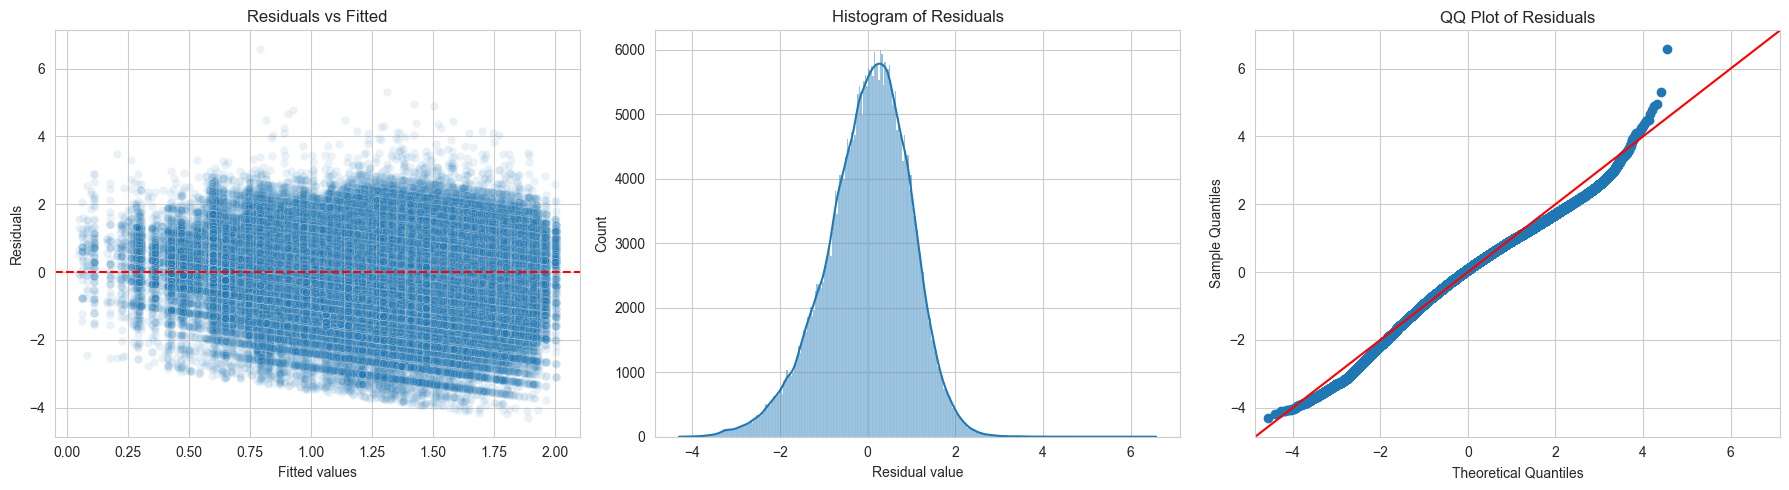

No diagnostics plotting implemented for family='gaussian'.


In [5]:
plot_diagnostics(result)

In [6]:
# filter to only include people who received atleast one month of prison
expmnt_df = sent_df[sent_df["MNTHS_PRSN_NO_ALT"] > 1].copy()

# Create year bins
expmnt_df["FISCAL_YR"] = pd.cut(expmnt_df["FISCAL_YR"], bins=[2010, 2015, 2020], labels=["2011-2015", "2016-2020"])


# scale MNTHS_PRSN_NO_ALT to reduce runtime of mixed model fitting and help convergence
expmnt_df["MNTHS_PRSN_NO_ALT"] = expmnt_df["MNTHS_PRSN_NO_ALT"] / 12  

expmnt_df["MNTHS_PRSN_NO_ALT"] = np.log(expmnt_df["MNTHS_PRSN_NO_ALT"])  # log transform to reduce skew

result = fit_mixed_model(
    expmnt_df[["MNTHS_PRSN_NO_ALT", "DIST_CRT", "RACE", "SEX", "FISCAL_YR"]], 
    formula="MNTHS_PRSN_NO_ALT ~ RACE + SEX + (1 | DIST_CRT) + (RACE + SEX | FISCAL_YR)",  
    family="gaussian",  
    link=None,  
    categorical_cols=["DIST_CRT", "RACE", "SEX", "FISCAL_YR"], 
    reference_levels = {"RACE": "White", "SEX": "Male", "FISCAL_YR": "2011-2015"},
    return_confint=False,  
    return_random_effects_variance=True,
    return_random_effects_covariance=True,  
    return_fitted=True, 
    return_residuals=True,  
    optimizer = "bobyqa",  
    keep_raw_summary=True, 
    return_random_effects=True,  
    r_script_path=os.path.join("r", "fit_mixed_model.R"),  
    r_executable="c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe" 
)
print(result.raw_summary)
print(f"\n\nErrors:\n", result.errors or "None", "\n\nWarnings:\n", result.warnings or "None")

Fitting mixed model with formula: MNTHS_PRSN_NO_ALT ~ RACE + SEX + (1 | DIST_CRT) + (RACE + SEX | FISCAL_YR), family: gaussian, optimizer: bobyqa...
Seconds taken to fit mixed model: 2558.77
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: fml
   Data: data
 Offset: if (!is.null(offset)) data[[offset]] else NULL
Control: ctrl

REML criterion at convergence: 1056371

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.4662 -0.6134  0.0830  0.6940  6.8596 

Random effects:
 Groups    Name         Variance Std.Dev. Corr                    
 DIST_CRT  (Intercept)  0.046464 0.21556                          
 FISCAL_YR (Intercept)  0.014346 0.11978                          
           RACEBlack    0.011554 0.10749  -0.98                   
           RACEHispanic 0.003491 0.05909  -0.93  0.98             
           RACEOther    0.002150 0.04637  -0.89  0.96  0.99       
           SEXFemale    0.001170 0.03420   0.82 -0.91 -0.97 -0.99

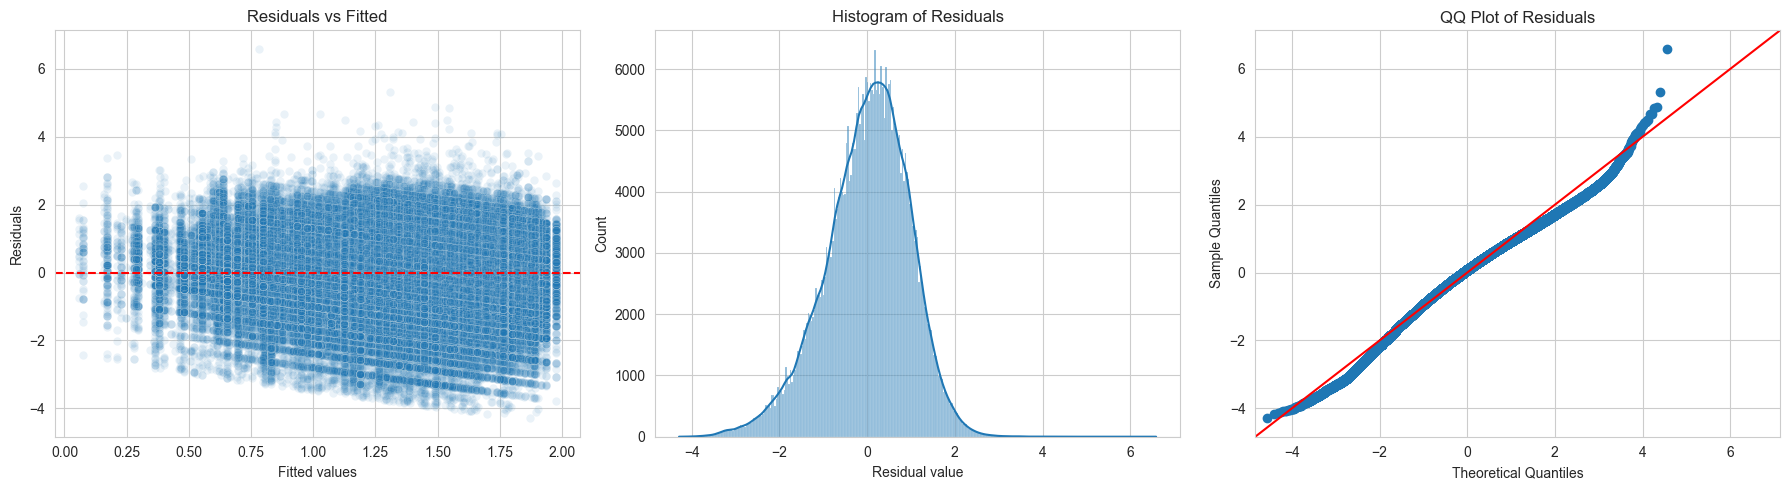

No diagnostics plotting implemented for family='gaussian'.


In [7]:
plot_diagnostics(result)

In [10]:
sent_df.columns[:100]

Index(['FISCAL_YR', 'SENT_RANGE_2004_2017', 'ZONE_OF_SENT',
       'MNTHS_PRSN_NO_ALT', 'ARMD_CAREER_CRIM_ST', 'ACC_RESP_ADJ', 'AGE',
       'CR_OFNDR_FLAG', 'DIST_CRT', 'CITIZEN', 'CTRY_OF_CTZNSHP',
       'OL_B4_ACC_RESP', 'ANY_CRIM_HIST_FLAG', 'EDUCATION', 'VAR_FSA_SFTY_VLV',
       'ORGN_DPTR_NOT_FROM_PLEA1', 'ORGN_DPTR_NOT_FROM_PLEA2',
       'ORGN_DPTR_NOT_FROM_PLEA3', 'ORGN_DPTR_NOT_FROM_PLEA4',
       'ORGN_DPTR_NOT_FROM_PLEA5', 'ORGN_DPTR_NOT_FROM_PLEA6',
       'ORGN_DPTR_NOT_FROM_PLEA7', 'ORGN_DPTR_NOT_FROM_PLEA8',
       'ORGN_DPTR_NOT_FROM_PLEA9', 'ORGN_DPTR_NOT_FROM_PLEA10',
       'ORGN_DPTR_NOT_FROM_PLEA11', 'ORGN_DPTR_NOT_FROM_PLEA12',
       'ORGN_DPTR_FROM_PLEA1', 'ORGN_DPTR_FROM_PLEA2', 'ORGN_DPTR_FROM_PLEA3',
       'ORGN_DPTR_FROM_PLEA4', 'ORGN_DPTR_FROM_PLEA5', 'ORGN_DPTR_FROM_PLEA6',
       'ORGN_DPTR_FROM_PLEA7', 'ORGN_DPTR_FROM_PLEA8', 'ORGN_DPTR_FROM_PLEA9',
       'ORGN_DPTR_FROM_PLEA10', 'ORGN_DPTR_FROM_PLEA11',
       'ORGN_DPTR_FROM_PLEA12', 'RCVD_PRIS_SE

In [13]:
sent_df['SENT_RANGE_2018_PRSNT'].value_counts()

SENT_RANGE_2018_PRSNT
Within Range                    104071
Below Range Variance             71092
5K1.1/Substantial Assistance     40946
Govt. Sponsored Variance         30226
Early Disposition/5K3.1           8645
Above Range Variance              6933
Govt. Sponsored Departure         6897
Downward Departure                5123
Upward Departure                  1725
Name: count, dtype: int64

In [ ]:
# filter to only include people who received atleast one month of prison
expmnt_df = sent_df[sent_df["MNTHS_PRSN_NO_ALT"] > 1].copy()

# filter out departures
expmnt_df = expmnt_df[(expmnt_df["SENT_RANGE_2018_PRSNT"] != 'Govt. Sponsored Departure') & (expmnt_df["SENT_RANGE_2018_PRSNT"] != 'Downward Departure') & (expmnt_df["SENT_RANGE_2018_PRSNT"] != 'Upward Departure')]

# To match the departures, filter out years prior to 2018
expmnt_df = expmnt_df[expmnt_df["FISCAL_YR"] >= 2018]

# scale MNTHS_PRSN_NO_ALT to reduce runtime of mixed model fitting and help convergence
expmnt_df["MNTHS_PRSN_NO_ALT"] = expmnt_df["MNTHS_PRSN_NO_ALT"] / 12  

expmnt_df["MNTHS_PRSN_NO_ALT"] = np.log(expmnt_df["MNTHS_PRSN_NO_ALT"])  # log transform to reduce skew

result = fit_mixed_model(
    expmnt_df[["MNTHS_PRSN_NO_ALT", "DIST_CRT", "RACE", "SEX", "FISCAL_YR"]], 
    formula="MNTHS_PRSN_NO_ALT ~ RACE + SEX + (1 | DIST_CRT) + (RACE + SEX | FISCAL_YR)",  
    family="gaussian",  
    link=None,  
    categorical_cols=["DIST_CRT", "RACE", "SEX", "FISCAL_YR"], 
    reference_levels = {"RACE": "White", "SEX": "Male", "FISCAL_YR": "2018"},
    return_confint=False,  
    return_random_effects_variance=True,
    return_random_effects_covariance=True,  
    return_fitted=True, 
    return_residuals=True,  
    optimizer = "bobyqa",  
    keep_raw_summary=True, 
    return_random_effects=True,  
    r_script_path=os.path.join("r", "fit_mixed_model.R"),  
    r_executable="c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe" 
)
print(result.raw_summary)
print(f"\n\nErrors:\n", result.errors or "None", "\n\nWarnings:\n", result.warnings or "None")

Fitting mixed model with formula: MNTHS_PRSN_NO_ALT ~ RACE + SEX + (1 | DIST_CRT) + (RACE + SEX | FISCAL_YR), family: gaussian, optimizer: bobyqa...
Seconds taken to fit mixed model: 543.76
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: fml
   Data: data
 Offset: if (!is.null(offset)) data[[offset]] else NULL
Control: ctrl

REML criterion at convergence: 619701.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3871 -0.6060  0.0843  0.6910  5.1157 

Random effects:
 Groups    Name         Variance  Std.Dev. Corr                    
 DIST_CRT  (Intercept)  0.0532375 0.23073                          
 FISCAL_YR (Intercept)  0.0031947 0.05652                          
           RACEBlack    0.0008874 0.02979  -0.77                   
           RACEHispanic 0.0003689 0.01921  -0.16  0.57             
           RACEOther    0.0014804 0.03848  -0.14  0.20  0.31       
           SEXFemale    0.0018654 0.04319  -0.73  0.16 -0.5

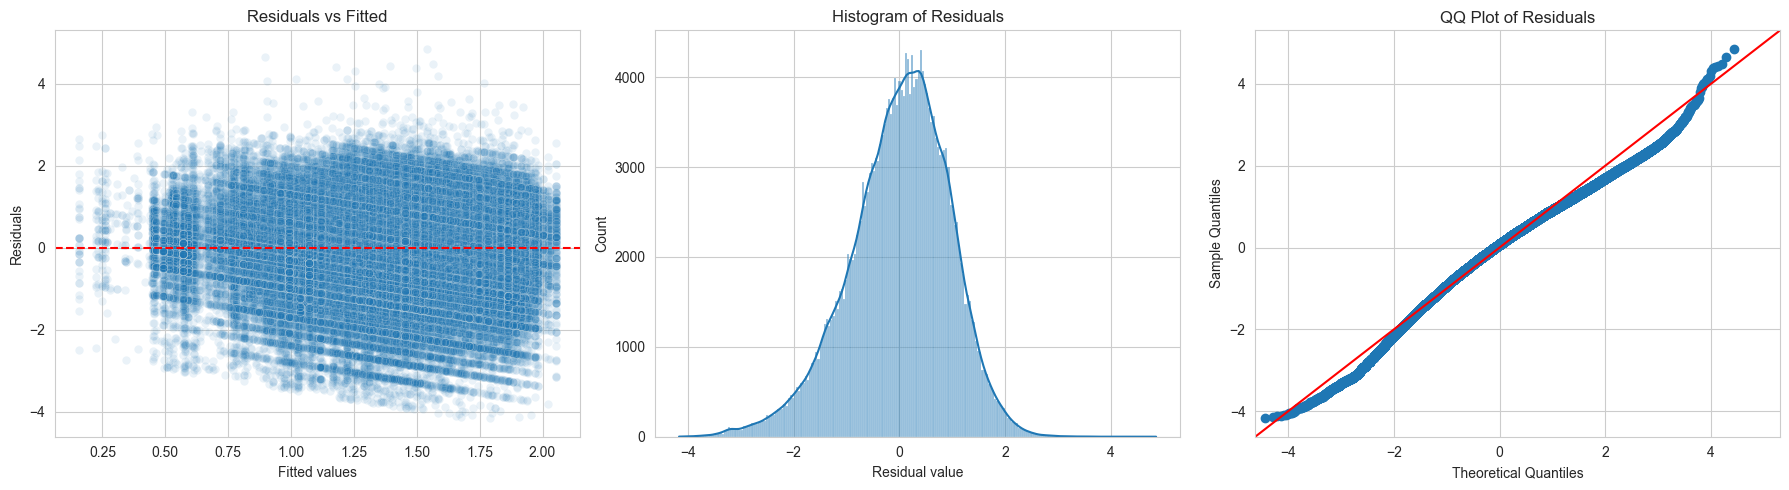

No diagnostics plotting implemented for family='gaussian'.


In [18]:
plot_diagnostics(result)

In [20]:
# filter to only include people who received atleast one month of prison
expmnt_df = sent_df[sent_df["MNTHS_PRSN_NO_ALT"] > 1].copy()

# filter out departures
expmnt_df = expmnt_df[(expmnt_df["SENT_RANGE_2018_PRSNT"] != 'Govt. Sponsored Departure') & (expmnt_df["SENT_RANGE_2018_PRSNT"] != 'Downward Departure') & (expmnt_df["SENT_RANGE_2018_PRSNT"] != 'Upward Departure')]

# To match the departures, filter out years prior to 2018
expmnt_df = expmnt_df[expmnt_df["FISCAL_YR"] >= 2018]

# scale MNTHS_PRSN_NO_ALT to reduce runtime of mixed model fitting and help convergence
expmnt_df["MNTHS_PRSN_NO_ALT"] = expmnt_df["MNTHS_PRSN_NO_ALT"] / 12  

expmnt_df["MNTHS_PRSN_NO_ALT"] = np.log(expmnt_df["MNTHS_PRSN_NO_ALT"])  # log transform to reduce skew

# Create year bins: 2018-2019, 2020-2021, 2022-2024 (combine 2022-2024 to ensure we have enough data in each bin after filtering out departures)
expmnt_df["FISCAL_YR"] = pd.cut(expmnt_df["FISCAL_YR"], bins=[2018, 2020, 2024, 2025], labels=["2018-2019", "2020-2021", "2022-2024"])

result = fit_mixed_model(
    expmnt_df[["MNTHS_PRSN_NO_ALT", "DIST_CRT", "RACE", "SEX", "FISCAL_YR"]], 
    formula="MNTHS_PRSN_NO_ALT ~ RACE + SEX + (1 | DIST_CRT) + (RACE + SEX | FISCAL_YR)",  
    family="gaussian",  
    link=None,  
    categorical_cols=["DIST_CRT", "RACE", "SEX", "FISCAL_YR"], 
    reference_levels = {"RACE": "White", "SEX": "Male", "FISCAL_YR": "2018-2019"},
    return_confint=False,  
    return_random_effects_variance=True,
    return_random_effects_covariance=True,  
    return_fitted=True, 
    return_residuals=True,  
    optimizer = "bobyqa",  
    keep_raw_summary=True, 
    return_random_effects=True,  
    r_script_path=os.path.join("r", "fit_mixed_model.R"),  
    r_executable="c:\\Program Files\\R\\R-4.5.2\\bin\\Rscript.exe" 
)
print(result.raw_summary)
print(f"\n\nErrors:\n", result.errors or "None", "\n\nWarnings:\n", result.warnings or "None")

Fitting mixed model with formula: MNTHS_PRSN_NO_ALT ~ RACE + SEX + (1 | DIST_CRT) + (RACE + SEX | FISCAL_YR), family: gaussian, optimizer: bobyqa...
Seconds taken to fit mixed model: 797.05
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: fml
   Data: data
 Offset: if (!is.null(offset)) data[[offset]] else NULL
Control: ctrl

REML criterion at convergence: 619841.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3832 -0.6064  0.0849  0.6909  5.0626 

Random effects:
 Groups    Name         Variance  Std.Dev. Corr                    
 DIST_CRT  (Intercept)  0.0531676 0.23058                          
 FISCAL_YR (Intercept)  0.0030281 0.05503                          
           RACEBlack    0.0011813 0.03437  -0.94                   
           RACEHispanic 0.0002823 0.01680  -0.62  0.84             
           RACEOther    0.0013111 0.03621  -0.03 -0.30 -0.77       
           SEXFemale    0.0004411 0.02100  -0.74  0.48 -0.0

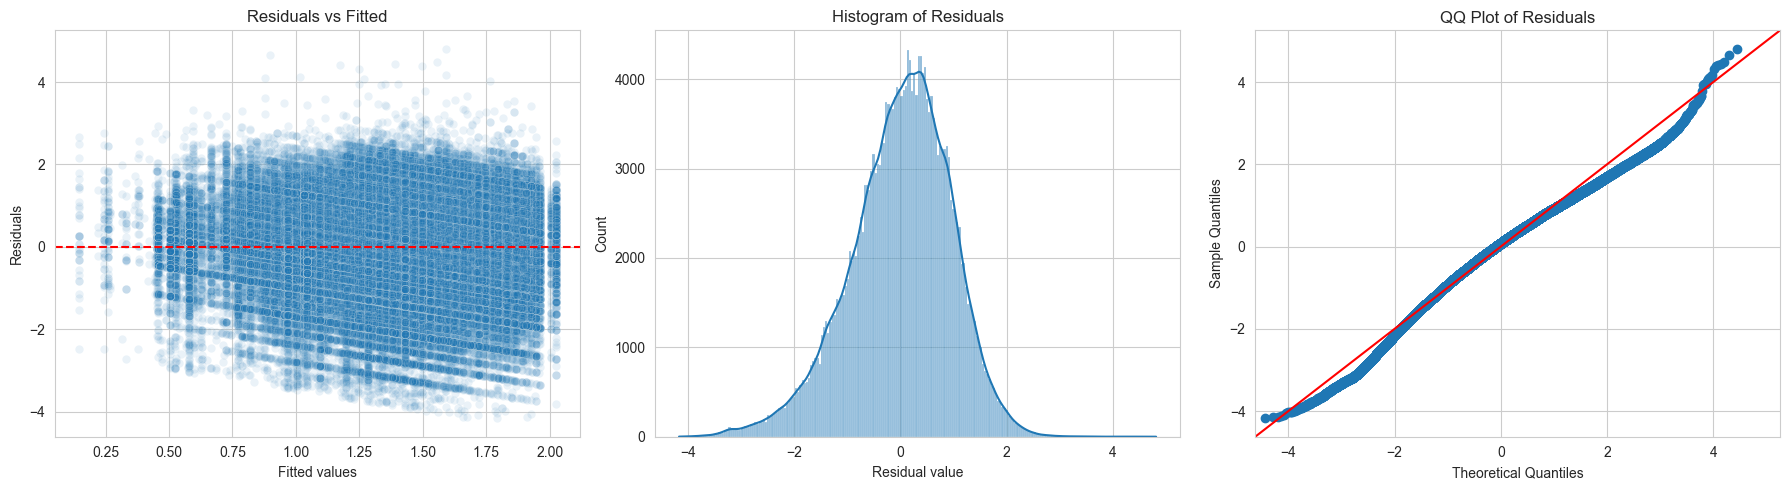

No diagnostics plotting implemented for family='gaussian'.


In [21]:
plot_diagnostics(result)